<a href="https://colab.research.google.com/github/sakshi-26769/capstone-project/blob/main/banking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_1 = pd.read_excel("/content/Data Dictionary.xlsx")
df_1.head()

,Variable Name,Description,Unnamed: 2
0,UniqueID,Identifier for customers,NaN
1,loan_default,Payment default in the first EMI on due date,NaN
2,disbursed_amount,Amount of Loan disbursed,NaN
3,asset_cost,Cost of the Asset,NaN
4,ltv,Loan to Value of the asset,NaN


Importing, Understanding, and Inspecting Data:
1. Perform preliminary data inspection and report the findings as the structure of the data, missing values, duplicates, etc.
2. Variable names in the data may not be in accordance with the identifier naming in Python so, change the variable names accordingly
3. The presented data might also contain some missing values therefore, exploration will also lead to devising strategies to fill in the missing values while exploring the data

In [ ]:
df = pd.read_excel("/content/data.xlsx")
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,420825,50578,58400,89.55,67,22807,45,1441,1984-01-01,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,417566,53278,61360,89.63,67,22807,45,1497,1985-08-24,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
2,539055,52378,60300,88.39,67,22807,45,1495,1977-12-09,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1
3,529269,46349,61500,76.42,67,22807,45,1502,1988-06-01,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
4,563215,43594,78256,57.50,67,22744,86,1499,1994-07-14,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   UniqueID                             233154 non-null  int64         
 1   disbursed_amount                     233154 non-null  int64         
 2   asset_cost                           233154 non-null  int64         
 3   ltv                                  233154 non-null  float64       
 4   branch_id                            233154 non-null  int64         
 5   supplier_id                          233154 non-null  int64         
 6   manufacturer_id                      233154 non-null  int64         
 7   Current_pincode_ID                   233154 non-null  int64         
 8   Date.of.Birth                        233154 non-null  datetime64[ns]
 9   Employment.Type                      225493 non-null  object        
 

In [ ]:
df.shape

(233154, 41)

In [ ]:
df.describe()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,DisbursalDate,...,SEC.OVERDUE.ACCTS,SEC.CURRENT.BALANCE,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,NO.OF_INQUIRIES,loan_default
count,233154.000000,233154.000000,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154,233154,...,233154.000000,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000
mean,535917.573376,54356.993528,7.586507e+04,74.746530,72.936094,19638.635035,69.028054,3396.880247,1984-04-04 04:32:39.947502400,2018-09-23 09:57:53.079595520,...,0.007244,5.427793e+03,7.295923e+03,7.179998e+03,1.310548e+04,3.232684e+02,0.381833,0.097481,0.206615,0.217071
min,417428.000000,13320.000000,3.700000e+04,10.030000,1.000000,10524.000000,45.000000,1.000000,1949-09-15 00:00:00,2018-08-01 00:00:00,...,0.000000,-5.746470e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,476786.250000,47145.000000,6.571700e+04,68.880000,14.000000,16535.000000,48.000000,1511.000000,1977-05-04 00:00:00,2018-08-30 00:00:00,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,535978.500000,53803.000000,7.094600e+04,76.800000,61.000000,20333.000000,86.000000,2970.000000,1986-01-01 00:00:00,2018-09-25 00:00:00,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,595039.750000,60413.000000,7.920175e+04,83.670000,130.000000,23000.000000,86.000000,5677.000000,1992-05-19 00:00:00,2018-10-21 00:00:00,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.999000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,671084.000000,990572.000000,1.628992e+06,95.000000,261.000000,24803.000000,156.000000,7345.000000,2000-10-20 00:00:00,2018-10-31 00:00:00,...,8.000000,3.603285e+07,3.000000e+07,3.000000e+07,2.564281e+07,4.170901e+06,35.000000,20.000000,36.000000,1.000000
std,68315.693711,12971.314171,1.894478e+04,11.456636,69.834995,3491.949566,22.141304,2238.147502,NaN,NaN,...,0.111079,1.702370e+05,1.831560e+05,1.825925e+05,1.513679e+05,1.555369e+04,0.955107,0.384439,0.706498,0.412252


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Employment.Type,7661
disbursed_amount,0
asset_cost,0
ltv,0
branch_id,0
supplier_id,0
manufacturer_id,0
Current_pincode_ID,0
UniqueID,0
Date.of.Birth,0


In [ ]:
df['Employment.Type'].fillna(df['Employment.Type'].mode()[0], inplace=True)

In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
df.columns = df.columns.str.replace('.', '_')
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.lower()

In [ ]:
df.columns

Performing EDA:
4. Provide the statistical description of the quantitative data variables
5. Explain how is the target variable distributed overall
6. Study the distribution of the target variable across various categories like branch, city, state, branch, supplier, manufacturer, etc.
7. What are the different employment types given in the data? Can a strategy be developed to fill in the missing values (if any)?  Use pie charts to express the different types of employment that define the defaulters and non-defaulters.
8. Has age got anything to do with defaulting? What is the distribution of age w.r.t. to the defaulters and non-defaulters?
9. What type of ID was presented by most of the customers for proof?

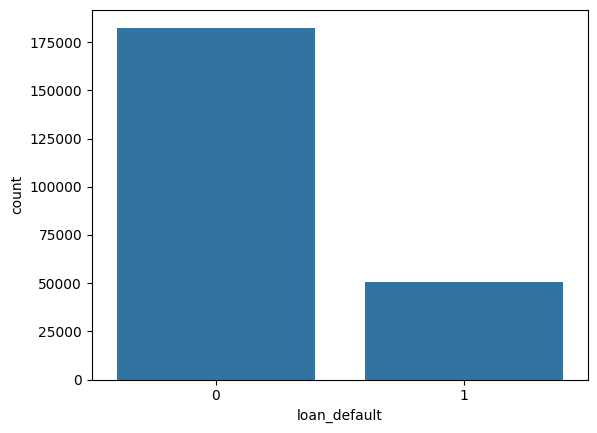

In [ ]:
# Target Variable Distribution
df['loan_default'].value_counts()
sns.countplot(x='loan_default', data=df)
plt.show()

In [ ]:
# Default Distribution by Categories
# By Branch
pd.crosstab(df['branch_id'], df['loan_default'], normalize='index')

loan_default,0,1
branch_id,,
1,0.850587,0.149413
2,0.813137,0.186863
3,0.825135,0.174865
5,0.777934,0.222066
7,0.796400,0.203600
...,...,...
257,0.801752,0.198248
258,0.794118,0.205882
259,0.771676,0.228324


In [ ]:
# By City / State / Manufacturer / Supplier
pd.crosstab(df['manufacturer_id'], df['loan_default'], normalize='index')

loan_default,0,1
manufacturer_id,,
45,0.771501,0.228499
48,0.727469,0.272531
49,0.781213,0.218787
51,0.792053,0.207947
67,0.782536,0.217464
86,0.795406,0.204594
120,0.779250,0.220750
145,0.799486,0.200514
152,1.000000,0.000000


In [ ]:
# Employment Type Analysis
df['employment_type'].value_counts()

,count
employment_type,
Self employed,135296
Salaried,97858


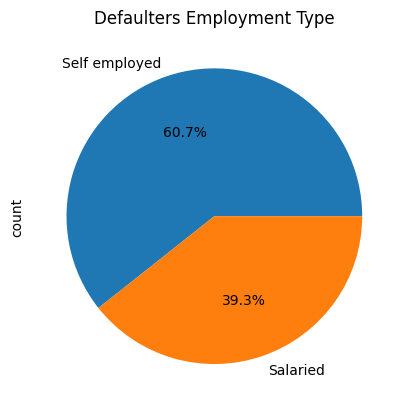

In [ ]:
df_default = df[df['loan_default']==1]
df_non_default = df[df['loan_default']==0]
df_default['employment_type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Defaulters Employment Type")
plt.show()

In [ ]:
# Age vs Default
df['age'] = 2018 - df['date_of_birth'].dt.year

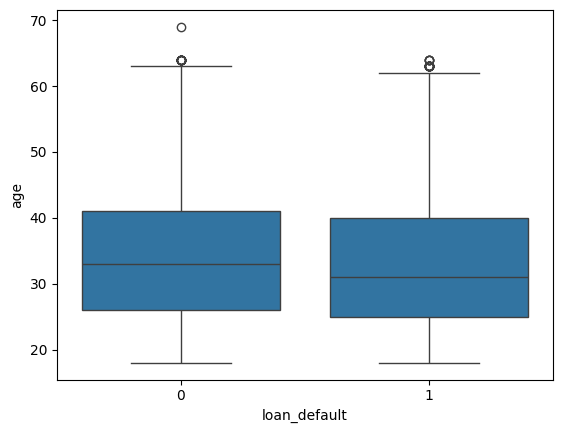

In [ ]:
sns.boxplot(x='loan_default', y='age', data=df)
plt.show()

In [ ]:
# Type of ID Presented
df['aadhar_flag'].sum()
df['pan_flag'].sum()
df['voterid_flag'].sum()
df['passport_flag'].sum()

np.int64(496)

Performing EDA and Modeling:
1. Study the credit bureau score distribution. Compare the distribution for defaulters vs. non-defaulters. Explore in detail.
2. Explore the primary and secondary account details. Is the information in some way related to the loan default probability?
3. Is there a difference between the sanctioned and disbursed amount of primary and secondary loans? Study the difference by providing appropriate statistics and graphs.
4. Do customer who make higher number of enquiries end up being higher risk candidates?
5. Is credit history, that is new loans in last six months, loans defaulted in last six months, time since first loan, etc., a significant factor in estimating probability of loan defaulters?
6. Perform logistic regression modeling, predict the outcome for the test data, and validate the results using the confusion matrix.


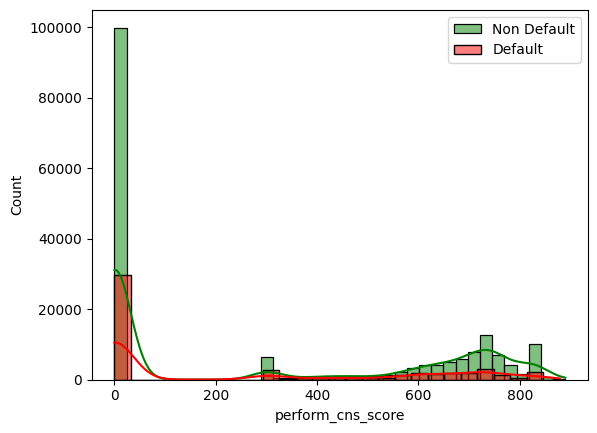

In [ ]:
# Credit Bureau Score Distribution
sns.histplot(df[df['loan_default']==0]['perform_cns_score'], color='green', label='Non Default', kde=True)
sns.histplot(df[df['loan_default']==1]['perform_cns_score'], color='red', label='Default', kde=True)
plt.legend()
plt.show()

<Axes: xlabel='loan_default', ylabel='pri_no_of_accts'>

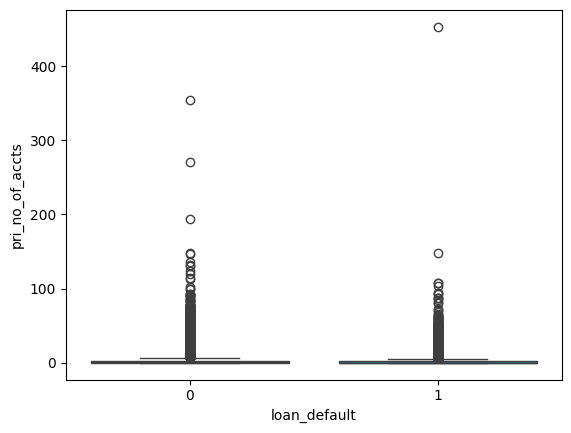

In [ ]:
#Primary & Secondary Account Details
sns.boxplot(x='loan_default', y='pri_no_of_accts', data=df)

In [ ]:
# Sanctioned vs Disbursed Amount
df['pri_diff'] = df['pri_sanctioned_amount'] - df['pri_disbursed_amount']
df['sec_diff'] = df['sec_sanctioned_amount'] - df['sec_disbursed_amount']

<Axes: xlabel='loan_default', ylabel='pri_diff'>

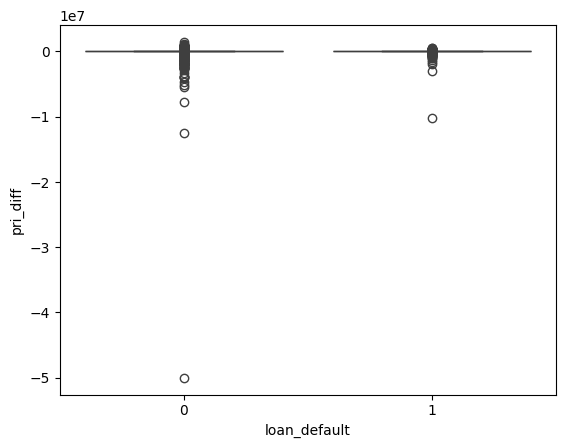

In [ ]:
sns.boxplot(x='loan_default', y='pri_diff', data=df)

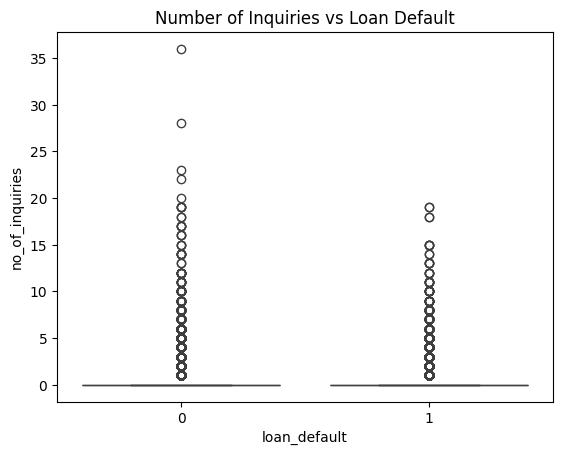

In [ ]:
# Number of Enquiries
sns.boxplot(x='loan_default', y='no_of_inquiries', data=df)
plt.title("Number of Inquiries vs Loan Default")
plt.show()

In [ ]:
df.groupby('loan_default')['no_of_inquiries'].mean()

,no_of_inquiries
loan_default,
0,0.190366
1,0.265219


In [ ]:
# Credit History Factors
pd.crosstab(df['new_accts_in_last_six_months'], df['loan_default'], normalize='index')

loan_default,0,1
new_accts_in_last_six_months,,
0,0.775849,0.224151
1,0.801738,0.198262
2,0.810803,0.189197
3,0.827725,0.172275
4,0.822177,0.177823
5,0.829876,0.170124
6,0.829167,0.170833
7,0.844371,0.155629
8,0.836735,0.163265


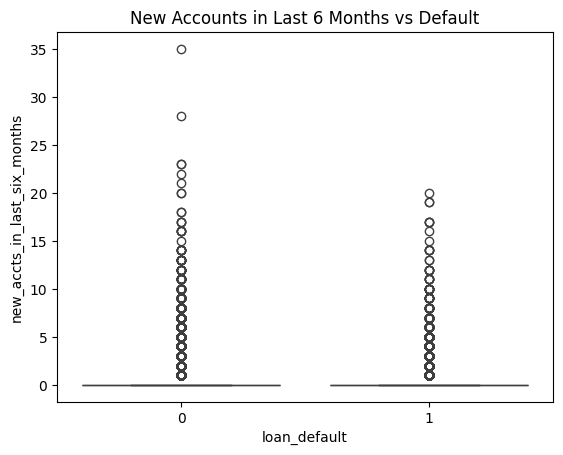

In [ ]:
sns.boxplot(x='loan_default',
            y='new_accts_in_last_six_months',
            data=df)
plt.title("New Accounts in Last 6 Months vs Default")
plt.show()

In [ ]:
#Convert Date Columns
df['Date.of.Birth'] = pd.to_datetime(df['Date.of.Birth'])
df['DisbursalDate'] = pd.to_datetime(df['DisbursalDate'])

In [ ]:
df['age'] = 2018 - df['Date.of.Birth'].dt.year

In [ ]:
df.drop(['Date.of.Birth'], axis=1, inplace=True)

In [ ]:
# Define X and y
X = df.drop(['loan_default', 'UniqueID', 'DisbursalDate'], axis=1)
y = df['loan_default']

In [ ]:
#Convert Categorical Variables
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

In [ ]:
#Prediction
y_pred = model.predict(X_test)

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55048     4]
 [14894     1]]


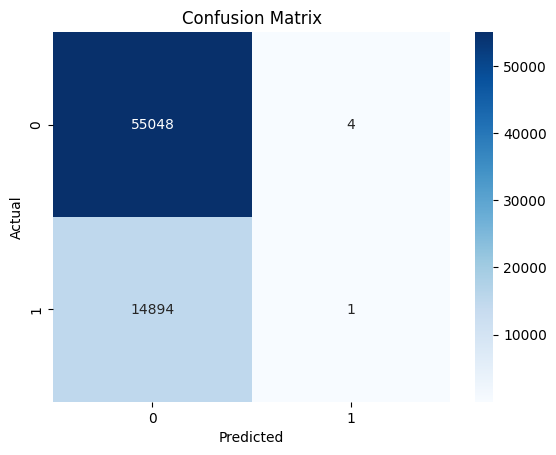

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88     55052
           1       0.20      0.00      0.00     14895

    accuracy                           0.79     69947
   macro avg       0.49      0.50      0.44     69947
weighted avg       0.66      0.79      0.69     69947



In [ ]:
#Export Clean Data
df.to_csv("clean_vehicle_loan_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("clean_vehicle_loan_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>